# CP01_assignment

**Name (Group Members):**  
- Guanru Su：Completed Question 1; implemented the IEEE Baby floating-point format and completed the related computations and analysis.
- Kevin Gonzalez Gordillo: Doing Question 2.
- Matthew VandenBoom:

---

**General Instructions:**

* Verify which group you are in.
* Replace the names above with the names of your actual group members, and make note of their degree of participation.
* Add all group members to the submission **via Gradescope** so that the autograder may assign them their grades. You will recieve an email when you have been added to an assignment via gradescope.
* Make sure all code is in a code cell.
* Please ensure that your code assigns the correct value to each of the provided variables so the autograder may grade your assignment correctly. **Do not change the names of any of the variables or functions**. **Do not edit the .ipynb in a text editor**. **Do not change the instruction cells**.
* Please put comments in your code.
* **If you have any questions about this .ipynb or need help with CP01, please contact your TA, Dylan Connell.**

**Please note:** This assignment involves both theoretical and computational exercises.

---

**Instructions for importing modules:**

* Try to only import allowed Python modules in the question that they have been permitted to be used in. Imports in the preamble (before the beginning of Question 1) may be rejected if they are not allowed to be used in all questions.

- **Question 1:** Use `matplotlib` to plot the list of all IEEE Baby-representable numbers. You may also use the `numpy` and `math` libraries.
- **Question 2:** You may import the `math` library for use in Question 2.
- **Question 3:** You may import the `math` library for use in Question 3.

**Recommended packages to import in your code cells:**

```python
import matplotlib.pyplot as plt # for question 1
import numpy as np # for question 1
import math # for questions 1-3
```

---

## Question 1: The IEEE Baby Floating Point Format

Define `ieee_baby` to be a function which accepts a string containing a 6-bit representation of a number in IEEE Baby format and returns the corresponding real number, where the 6 bits in the input represent the following:
- The first bit is the sign bit.
- The second and third bits are allocated to the characteristic.
- The fourth, fifth, and sixth bits are allocated to the fraction.
- The normalization for the characteristic is 1.
- Only consider the normal case, and do not reserve any floating points to represent special numbers such as infinity.

For example, here is how we compute the decimal number from the Baby IEEE number `010010`:

| s | C  | f   |
|---|----|-----|
| 0 | 10 | 010 |

In this case, $s = 0$, $C = 2$ and $f = 2^{-2} = 0.25$.  
And our number is:  
$$
(-1)^s 2^{C-1}(1+f) = 1 \cdot 2^{2-1} \cdot (1.25) = 2.5
$$

Here is how the code should run:

#### Example use
```python
>>> ieee_baby('010010')
2.5
```

In [6]:
# -------------- CODE BELOW --------------
import matplotlib.pyplot as plt
import numpy as np
import math

def ieee_baby(baby):
    # Check if is a valid 6-bit binary string
    if not isinstance(baby, str) or len(baby) != 6:
        raise ValueError("Input must be a 6-bit string.")
    if any(bit not in "01" for bit in baby):
        raise ValueError("Input must contain only 0 and 1.")

    # Sign bit
    s = int(baby[0])

    # Two-bit characteristic
    C = int(baby[1:3], 2)

    # Three-bit fraction
    f = (
        int(baby[3]) * 2**(-1)
        + int(baby[4]) * 2**(-2)
        + int(baby[5]) * 2**(-3)
    )

    real = (-1)**s * 2**(C - 1) * (1 + f)

    return real

In [7]:
ieee_baby('010010')

2.5

**(a)** Make a list of all the possible numbers that can be stored in our IEEE Baby format and plot them on the number line using Matplotlib.

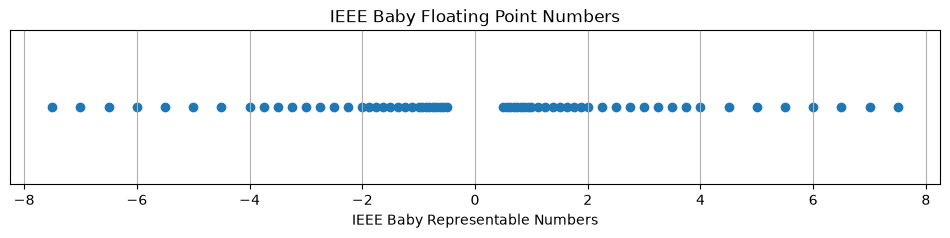

In [8]:
# -------------- CODE BELOW --------------
baby_list =  list() # Fill this list with all numbers that can be stored in IEEE Baby format.

# Generate all possible 6-bit IEEE Baby numbers
for i in range(64):
    baby = format(i, '06b')
    baby_list.append(ieee_baby(baby))

# Sort 
baby_list.sort()

# Plot 
plt.figure(figsize=(12, 2))
plt.scatter(baby_list, np.zeros(len(baby_list)))
plt.yticks([])
plt.xlabel("IEEE Baby Representable Numbers")
plt.title("IEEE Baby Floating Point Numbers")
plt.grid(axis="x")
plt.show()

**(b)** Provide a brief description of your observations from the plot in the cell below.

The IEEE Baby numbers are symmetric about zero. The representable numbers are not uniformly spaced. Numbers closer to zero have smaller gaps, while numbers with larger magnitudes have larger gaps.And only normal numbers are considered, zero is not representable. 

**(c)** What is the largest gap between two neighboring numbers and what is the smallest gap between any two neighboring positive numbers?

In [9]:
# -------------- CODE BELOW --------------
# Sort 
unique_numbers = sorted(set(baby_list))

# Compute gaps between neighboring numbers
gaps = [
    unique_numbers[i + 1] - unique_numbers[i]
    for i in range(len(unique_numbers) - 1)
]

largest_gap_between_numbers = max(gaps)

# Keep only positive numbers
positive_numbers = [x for x in unique_numbers if x > 0]

positive_gaps = [
    positive_numbers[i + 1] - positive_numbers[i]
    for i in range(len(positive_numbers) - 1)
]

smallest_gap_between_positive_numbers = min(positive_gaps)

print("Largest gap:", largest_gap_between_numbers)
print("Smallest positive gap:", smallest_gap_between_positive_numbers)

Largest gap: 1.0
Smallest positive gap: 0.0625


**(d)** What is the largest positive IEEE Baby float? What is the smallest positive IEEE Baby float?

In [10]:
# -------------- CODE BELOW --------------
positive_numbers = [x for x in baby_list if x > 0]

largest_positive = max(positive_numbers)
smallest_positive = min(positive_numbers)

print("Largest positive:", largest_positive)
print("Smallest positive:", smallest_positive)

Largest positive: 7.5
Smallest positive: 0.5


**(e)** Convert `1.25` and `1.0` into IEEE Baby format. Then, rounding to the nearest if necessary, compute the value of `1.25 - 1.0` using the IEEE Baby format (i.e., add the representations as stored in IEEE Baby, not in standard Python float). 

In [11]:
# -------------- CODE BELOW --------------
# 1.25 = 001010 in IEEE Baby format
baby_125 = '001010'

# 1.0 = 001000 in IEEE Baby format
baby_100 = '001000'

# Exact mathematical difference
exact_difference = ieee_baby(baby_125) - ieee_baby(baby_100)

# Round to the nearest representable IEEE Baby number
baby_sum = min(baby_list, key=lambda x: abs(x - exact_difference))

print("1.25 =", ieee_baby(baby_125))
print("1.0 =", ieee_baby(baby_100))
print("Exact difference =", exact_difference)
print("IEEE Baby result =", baby_sum)

1.25 = 1.25
1.0 = 1.0
Exact difference = 0.25
IEEE Baby result = 0.5


**(f)** Is the result, when converted to a real number, equal to `0.25`? Provide an explanation in the cell below.

No. The exact result is \(0.25\), but \(0.25\) cannot be represented in the IEEE Baby format. The smallest positive IEEE Baby number is \(0.5\). Therefore, when the exact result is rounded to the nearest representable IEEE Baby number, the stored result is \(0.5\), not \(0.25\).

---
## Question 2: Fixed-Point Iteration and Steffensen’s Method

For each of the equations below:

**(a)** $x = \dfrac{2 - e^{x} + x^2}{3}$

**(b)** $x = 0.5\,(\sin(x) + \cos(x))$

* **Step 1:** Show your work to demonstrate that a fixed point exists for each equation, and find an interval $[a, b]$ containing the fixed point such that $|g'(x)| < 1$ for all x in the interval.  
* **Step 2:** Write a function `stef_method(f, x_0, tol, N)` that implements Steffensen’s method, where `f` is the fixed-point function, `x_0` is the initial guess, `tol` is the tolerance, and `N` is the maximum number of iterations.
* **Step 3:** Use your function to approximate the solution to each equation to within $10^{-5}$, and report the number of iterations, final approximation and $|f(p_n) - p_n|$ (the final residual). 

#### Example use
```python
import math

fp, iterations, residual = stef_method(
    lambda x: (2 - math.exp(x) + x**2) / 3,  # g(x) as a lambda
    x0=0.5,
    tol=1e-5,
    N=300
)

print("Fixed Point:", fp)
print("Iterations:", iterations)
print("Residual:", residual)

Fixed Point: 0.2575303177198077
Iterations: 2
Residual: 4.0658426792017366e-08
```

**Write your mathematical work for Step 1 below.**

### Step 1: Work for (a) and (b)
**(a)** Show all reasoning, interval checks, and fixed-point existence arguments for equation (a) here.

**(b)** Show all reasoning, interval checks, and fixed-point existence arguments for equation (b) here.

If you do not wish to type your work in LaTeX, you may upload photographs of your work in the cell below (copy and paste or drag and drop) or as part of your Gradescope upload.

### Step 2: Create code for Steffensen's Method.

Below is where you put the Python code for Steffensen's Method.

In [12]:
# -------------- CODE Here--------------
def stef_method(f, x0, tol, N):
    return fp

### Step 3: Report your results

In [13]:
# -------------- CODE Here--------------
root_a , iter_a, residual_a = [None, None, None] # Have stef_method return the root of equation a). along with the number of iterations and the residual

root_b, iter_b, residual_b = [None, None, None] # Have stef_method return the root of equation b). along with the number of iterations and residual

---
## Question 3: Bracketed Secant Root Solver

In this problem, you will explore a strategy for root-finding that combines the guaranteed convergence of the bisection method with the speed of the secant method.

### Function: `root_solver`

Write a Python function `root_solver` that takes the following arguments:
- `f`: a function which changes sign somewhere over the real numbers in a continuous manner and thus has a root
- `a`: lower bound of an interval $[a,b]$ with $f(a)*f(b) < 1$
- `b`: upper bound of an interval $[a,b]$ with $f(a)*f(b) < 1$
- `TOL`: a stopping tolerance
- `max_iter`: maximum number of iterations 


You will, at all times, keep track of two numbers, $a$ and $b$, $a < b$, between which you should know a root of $f$ lies. Attempt first to produce a number $c$ using the secant method, and if you know that a root of $f$ lies between $c$ and $b$, then repeat this process, letting $c$ and $b$ be the $a$ and $b$ of the next iteration. If there is not a root between $c$ and $b$, then repeat this process, letting $a$ and $c$ be the $a$ and $b$ of the next iteration.

The secant method update rule is
$$
c = b - \frac{f(b)}{\frac{f(b) - f(a)}{b - a}} = b - \frac{f(b)(b - a)}{f(b) - f(a)}
$$

If, at the beginning of an iteration, $|b - a| < TOL$, or $\text{min}(|f(a)|,|f(b)|) < TOL$, or the number of iterations exceeds *max_iter*, return the endpoint that gives the smaller value as your approximation. 

*Hint: use `return min(a,b, key = lambda x: abs(f(x)))` to return the endpoint that gives the smaller absolute value of $f$*

*Note: Your function should check the correctness of its inputs and should make as few evaluations of $f$ as possible. Consider try-except blocks or condition checks for robust code, and refer to Section 2.7 of Tea Time Numerical Analysis for more details.*

Use your `root_solver` to approximate the following roots with a tolerance of $0.01$:

1. $f(x) = \frac{20x - 1}{19x}$ on $[0.01, 1]$
2. $f(x) = x^5 - x - 1$ on $[1,2]$
3. $f(x) = \sin(x) - 0.5$ on $[0, 2]$

#### Example use
```python
>>> root_solver(
    f = lambda x: math.arctan(x), 
    a=-1, 
    b=1.2, 
    TOL=0.01, 
    max_iter=1000
)
0.000004
```
| Step | a | b | f(c) | Replace | c | Dist (b-a) |
| :--- | :--- | :--- | :--- | :---: | :---: | :--- |
| 1 | -1.000000 | +1.200000 | +0.039956 | b | +0.039977 | 2.200000 |
| 2 | -1.000000 | +0.039977 | -0.010368 | a | -0.010369 | 1.039977 |
| 3 | -0.010369 | +0.039977 | +0.000004 | b | +0.000004 | 0.050346 |
| 4 | -0.010369 | +0.000004 | -0.000000 | a | -0.000000 | 0.010373 |

**Extra credit**: At each iteration, also use the bisection method update rule to find a smaller interval also containing a root of `f`. Compare it with the interval found using the secant method, and use the smaller interval (i.e. the one that yields a smaller |b - a|) as the `a` and `b` of the next iteration. Doing so will guarantee that $|b - a|$ decreases by at least half with each iteration.

The bisection method update rule is
$$
c = b + \frac{a-b}{2}
$$

**Write your function and your results in the cells below.**

In [14]:
# -------------- CODE Here--------------
def root_solver(f, a, b, TOL, max_iter):
    return root

x_1 = None
x_2 = None
x_3 = None